In [2]:
import os
import pickle
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

/Users/thiagosantana/steel-demand-forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
datetime_str = datetime.strftime(datetime.now(), '%Y-%m-%d_%H-%M-%S')
os.makedirs('./secoes/', exist_ok=True)
os.makedirs(f'./secoes/resultados_{datetime_str}', exist_ok=True)
path_secao_atual = f'./secoes/resultados_{datetime_str}'
print(f'Resultados serão salvos em: {path_secao_atual}')

Resultados serão salvos em: ./secoes/resultados_2026-06-30_06-30-21


In [4]:
os.makedirs('./Modelos', exist_ok=True)

In [5]:
pd.set_option('display.max_columns', None)

In [7]:
df_tabela_mestre = pd.read_excel('../dados/gold/tabela_mestre.xlsx', engine='openpyxl')

In [8]:
df_tabela_mestre.head()

,Date,Consumo Aparente,AUTOVEÍCULOS TOTAL_Produção,AUTOMÓVEIS_Produção,COMERCIAIS LEVES_Produção,CAMINHÕES_Produção,ÔNIBUS_Produção,producao_total,IPCA,PIB_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_infraestrutura,operacoes_credito_industria_metalurgia_siderurgia,Outra,km,kva,kw,m2,m3,VALUE (R$),taxa_selic_aa,24 METALURGIA,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS","27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS",28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS","30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES",3.24 Metalurgia,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias","3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",custo_projeto_m2
0,2014-06-01,852.989,215943,170647,34566,8190,2540,431886,0.40,461325.2,114449,28853,49127,15833280.08,206138.84,0.0,36.77,5731452.07,120894.28,1.489907,10.296141,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1445.08987,536.25142,774.63730,1163.22075,58.1,1822703.31
1,2014-07-01,974.740,254348,201533,37542,12322,2951,508696,0.01,486894.3,114323,29287,48528,19254140.05,155870.07,300231.0,644.80,7304573.29,60804.87,1.650081,12.014922,71.32037,76.83444,76.52759,81.05502,77.83338,62.11506,1559.18983,786.14218,911.41471,1335.39708,58.0,1835144.66
2,2014-08-01,963.083,264637,207872,41917,11988,2860,529274,0.25,483786.7,115139,29420,49022,7766089.42,82489.49,0.0,0.00,14593250.24,207038.88,1.535997,10.954329,71.57284,77.23915,76.89964,80.78251,78.33166,63.28233,1537.70330,779.68281,967.69409,1264.60564,57.9,1845380.76
3,2014-09-01,967.462,300931,236981,49385,11786,2779,601862,0.57,491444.4,115375,29808,49557,89105139.24,17847.52,0.0,1614.31,5380908.37,68406.00,1.710320,11.483469,73.27483,77.61533,76.98309,81.16512,79.65369,64.27091,1534.69506,781.46108,1029.12568,1264.35819,58.1,1848427.38
4,2014-10-01,1008.277,293328,229861,48378,12394,2695,586656,0.42,508979.3,116454,30192,49370,11984677.71,55837.25,0.0,741.90,6090839.48,12880.64,1.815994,12.014922,73.62697,78.31249,77.72763,81.12239,80.13525,66.48029,1627.02330,834.74725,984.29963,1276.37929,58.2,1855630.33


In [9]:
df_tabela_mestre.shape

(143, 33)

## 1. Análise Exploratória (EDA)

Colunas com valores nulos (%):
Series([], dtype: float64)


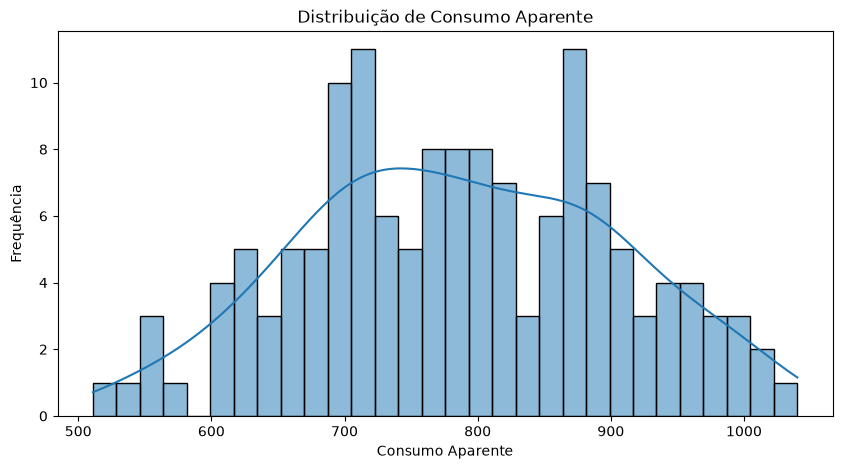

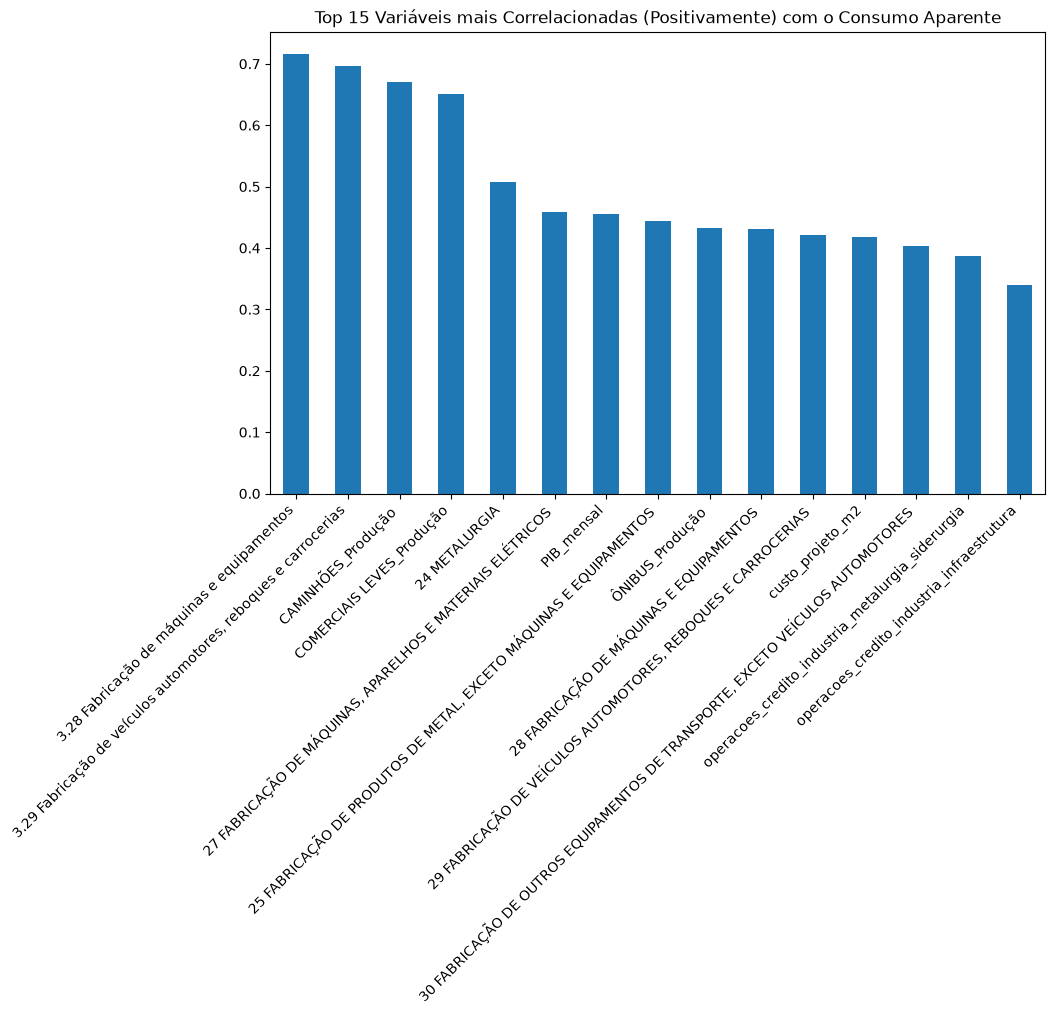

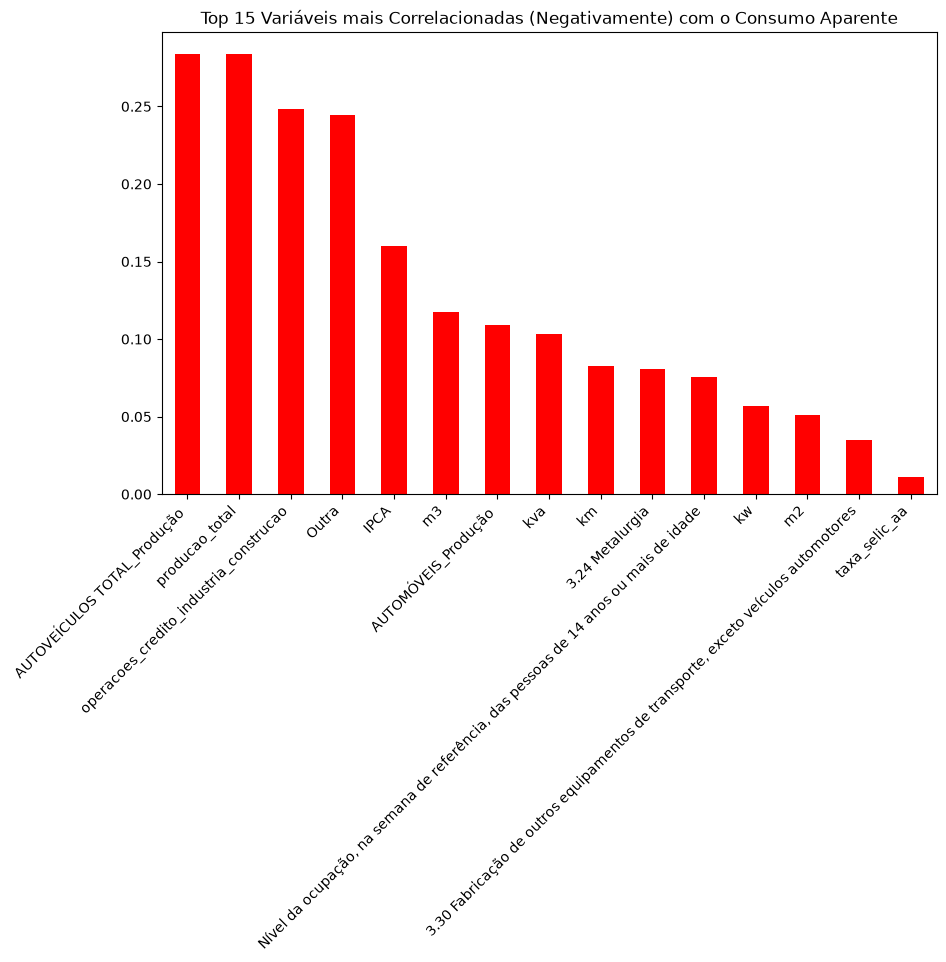

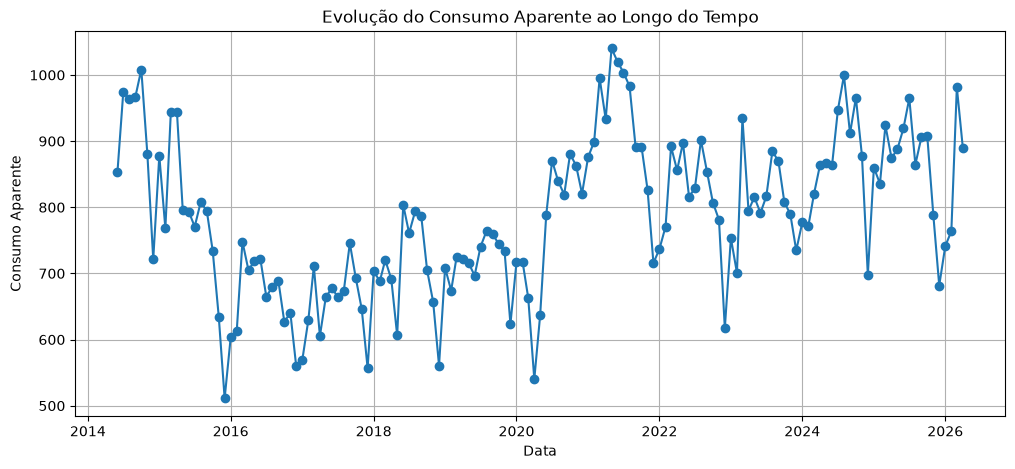

In [10]:
# Remover colunas com mais de 50% de nulos caso existam, ou apenas visualizar
missing = df_tabela_mestre.isnull().mean() * 100
print("Colunas com valores nulos (%):")
print(missing[missing > 0].sort_values(ascending=False))

# Distribuição da Variável Target
plt.figure(figsize=(10, 5))
sns.histplot(df_tabela_mestre['Consumo Aparente'], kde=True, bins=30)
plt.title('Distribuição de Consumo Aparente')
plt.xlabel('Consumo Aparente')
plt.ylabel('Frequência')
plt.show()

# Correlação com a variável Target (top 15)
numeric_df = df_tabela_mestre.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Consumo Aparente'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
correlations.drop('Consumo Aparente').head(15).plot(kind='bar')
plt.title('Top 15 Variáveis mais Correlacionadas (Positivamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Correlações Negativas (top 15)
plt.figure(figsize=(10, 6))
correlations.tail(15).plot(kind='bar', color='red')
plt.title('Top 15 Variáveis mais Correlacionadas (Negativamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Evolução do Consumo ao longo do tempo (se aplicável)
if 'Date' in df_tabela_mestre.columns:
    df_temp = df_tabela_mestre.copy()
    df_temp['Date'] = pd.to_datetime(df_temp['Date'])
    df_temp.sort_values('Date', inplace=True)
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_temp['Date'], df_temp['Consumo Aparente'], marker='o', linestyle='-')
    plt.title('Evolução do Consumo Aparente ao Longo do Tempo')
    plt.xlabel('Data')
    plt.ylabel('Consumo Aparente')
    plt.grid(True)
    plt.show()


## Remoção de Variáveis Muito Correlacionadas (Multicolinearidade)

In [11]:
# Removeremos a variável target da verificação para garantir que ela não seja removida
numeric_cols = df_tabela_mestre.select_dtypes(include=[np.number]).columns.tolist()
if 'Consumo Aparente' in numeric_cols:
    numeric_cols.remove('Consumo Aparente')

# Calcular matriz de correlação absoluta
corr_matrix = df_tabela_mestre[numeric_cols].corr().abs()

# Obter triângulo superior da matriz de correlação
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a 0.90
threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Variáveis muito correlacionadas a serem removidas ({len(to_drop)}):")
for col in to_drop:
    print(f" - {col}")

# Remover as colunas identificadas
df_tabela_mestre = df_tabela_mestre.drop(columns=to_drop)

print("\nShape do dataset após remoção das variáveis correlacionadas:", df_tabela_mestre.shape)

Variáveis muito correlacionadas a serem removidas (9):
 - AUTOMÓVEIS_Produção
 - producao_total
 - operacoes_credito_industria_infraestrutura
 - 25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS
 - 27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS
 - 28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS
 - 29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS
 - 30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES
 - custo_projeto_m2

Shape do dataset após remoção das variáveis correlacionadas: (143, 24)


## Seleção de Variáveis com RFECV (Random Forest)

In [12]:
df_tabela_mestre.head()

,Date,Consumo Aparente,AUTOVEÍCULOS TOTAL_Produção,COMERCIAIS LEVES_Produção,CAMINHÕES_Produção,ÔNIBUS_Produção,IPCA,PIB_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_metalurgia_siderurgia,Outra,km,kva,kw,m2,m3,VALUE (R$),taxa_selic_aa,24 METALURGIA,3.24 Metalurgia,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias","3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade"
0,2014-06-01,852.989,215943,34566,8190,2540,0.40,461325.2,114449,49127,15833280.08,206138.84,0.0,36.77,5731452.07,120894.28,1.489907,10.296141,71.51497,1445.08987,536.25142,774.63730,1163.22075,58.1
1,2014-07-01,974.740,254348,37542,12322,2951,0.01,486894.3,114323,48528,19254140.05,155870.07,300231.0,644.80,7304573.29,60804.87,1.650081,12.014922,71.32037,1559.18983,786.14218,911.41471,1335.39708,58.0
2,2014-08-01,963.083,264637,41917,11988,2860,0.25,483786.7,115139,49022,7766089.42,82489.49,0.0,0.00,14593250.24,207038.88,1.535997,10.954329,71.57284,1537.70330,779.68281,967.69409,1264.60564,57.9
3,2014-09-01,967.462,300931,49385,11786,2779,0.57,491444.4,115375,49557,89105139.24,17847.52,0.0,1614.31,5380908.37,68406.00,1.710320,11.483469,73.27483,1534.69506,781.46108,1029.12568,1264.35819,58.1
4,2014-10-01,1008.277,293328,48378,12394,2695,0.42,508979.3,116454,49370,11984677.71,55837.25,0.0,741.90,6090839.48,12880.64,1.815994,12.014922,73.62697,1627.02330,834.74725,984.29963,1276.37929,58.2


Treinando RFECV, isso pode demorar um pouco...


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Número ótimo de features selecionadas: 18

Top Features Selecionadas:
                                              Feature  Selecionada  Rank
0                         AUTOVEÍCULOS TOTAL_Produção         True     1
19  3.29 Fabricação de veículos automotores, reboq...         True     1
18         3.28 Fabricação de máquinas e equipamentos         True     1
17                                    3.24 Metalurgia         True     1
16                                      24 METALURGIA         True     1
15                                      taxa_selic_aa         True     1
14                                         VALUE (R$)         True     1
12                                                 m2         True     1
20  3.30 Fabricação de outros equipamentos de tran...         True     1
21  Nível da ocupação, na semana de referência, da...         True     1
8                                               Outra         True     1
7   operacoes_credito_industria_metalurgia_siderurgia 

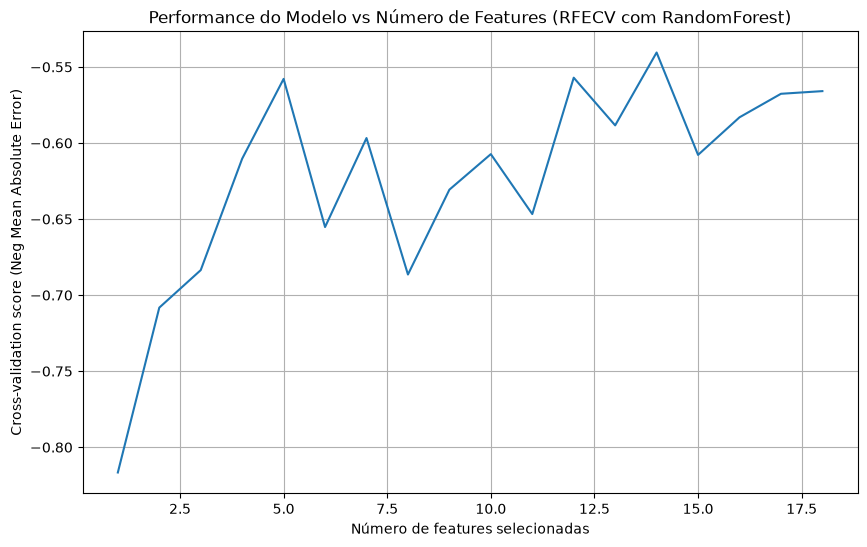


Shape do dataset após seleção do RFECV: (143, 20)


In [13]:
target_col = 'Consumo Aparente'

# Identificar dados numéricos e preencher nulos (necessário para o RFECV)
df_rfecv = df_tabela_mestre.copy()
if 'Date' in df_rfecv.columns:
    df_rfecv = df_rfecv.sort_values('Date').reset_index(drop=True)
    df_rfecv = df_rfecv.drop(columns=['Date'])

X_rfecv = df_rfecv.drop(columns=[target_col], errors='ignore').select_dtypes(include=[np.number])
# RFECV não aceita valores nulos, preenchendo temporariamente com a média
X_rfecv = X_rfecv.fillna(X_rfecv.mean())
y_rfecv = df_rfecv[target_col]

# Validação Cruzada temporal (TimeSeriesSplit) visto que é previsão de demanda
tscv = TimeSeriesSplit(n_splits=5)

# Modelo Base
rf_model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)

# Inicializar RFECV
# scoring='neg_mean_absolute_error'
rfecv = RFECV(estimator=rf_model, cv=tscv, scoring='r2', min_features_to_select=5, n_jobs=-1)

print("Treinando RFECV, isso pode demorar um pouco...")
rfecv.fit(X_rfecv, y_rfecv)

print(f"Número ótimo de features selecionadas: {rfecv.n_features_}")

# Features selecionadas
features_df = pd.DataFrame({
    'Feature': X_rfecv.columns,
    'Selecionada': rfecv.support_,
    'Rank': rfecv.ranking_
}).sort_values(by='Rank')

print("\nTop Features Selecionadas:")
print(features_df[features_df['Selecionada']].head(20))

# Plotar o resultado do cross-validation
plt.figure(figsize=(10, 6))
plt.title('Performance do Modelo vs Número de Features (RFECV com RandomForest)')
plt.xlabel("Número de features selecionadas")
plt.ylabel("Cross-validation score (Neg Mean Absolute Error)")
# cv_results_ contém o CV score para cada subset de features iterado
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.grid(True)
plt.show()

# Opcional: Atualizar o df_tabela_mestre para conter apenas as features selecionadas (além do target/Date)
to_keep = features_df[features_df['Selecionada']]['Feature'].tolist()
if 'Date' in df_tabela_mestre.columns:
    to_keep.append('Date')
to_keep.append(target_col)

df_tabela_mestre = df_tabela_mestre[to_keep]
print(f"\nShape do dataset após seleção do RFECV: {df_tabela_mestre.shape}")


## 2. Modelagem Preditiva

In [14]:
df_tabela_mestre.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,Date,Consumo Aparente
0,215943,774.63730,536.25142,1445.08987,71.51497,10.296141,1.489907,5731452.07,1163.22075,58.1,15833280.08,49127,461325.2,0.40,2540,8190,34566,206138.84,2014-06-01,852.989
1,254348,911.41471,786.14218,1559.18983,71.32037,12.014922,1.650081,7304573.29,1335.39708,58.0,19254140.05,48528,486894.3,0.01,2951,12322,37542,155870.07,2014-07-01,974.740
2,264637,967.69409,779.68281,1537.70330,71.57284,10.954329,1.535997,14593250.24,1264.60564,57.9,7766089.42,49022,483786.7,0.25,2860,11988,41917,82489.49,2014-08-01,963.083
3,300931,1029.12568,781.46108,1534.69506,73.27483,11.483469,1.710320,5380908.37,1264.35819,58.1,89105139.24,49557,491444.4,0.57,2779,11786,49385,17847.52,2014-09-01,967.462
4,293328,984.29963,834.74725,1627.02330,73.62697,12.014922,1.815994,6090839.48,1276.37929,58.2,11984677.71,49370,508979.3,0.42,2695,12394,48378,55837.25,2014-10-01,1008.277


In [15]:
df_tabela_mestre.tail()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,Date,Consumo Aparente
138,184474,704.52824,753.90239,1011.34938,176.73024,15.663411,5.452482,24814802.00,537.36830,58.9,2.609286e+08,57642,1084424.7,0.33,701,5723,38103,26004.51,2025-12-01,681.715
139,163672,679.80334,681.70730,1270.35700,181.58552,14.843349,5.337419,36277795.83,584.92357,58.7,2.630901e+08,54982,1027025.9,0.33,1884,6813,30782,57944.32,2026-01-01,741.387
140,207028,847.32653,756.72097,1162.92176,184.10920,12.682503,5.200011,17534956.13,526.51414,58.4,4.937053e+08,55442,1051261.2,0.70,2786,7797,41499,255940.31,2026-02-01,763.804
141,263608,1022.72777,856.34190,1158.69850,182.25140,15.526362,5.230982,33425577.58,574.39457,58.2,8.297629e+08,56877,1172691.8,0.88,3145,11133,50214,13122983.15,2026-03-01,981.477
142,238550,955.24230,700.60923,1206.50653,182.46862,13.893348,5.032475,33741187.44,529.95676,58.4,2.408977e+09,53760,1145657.0,0.67,3095,9673,42792,605488.71,2026-04-01,888.898


In [16]:
df_tabela_mestre.shape

(143, 20)

## Extrair ano e mês

In [17]:
df_tabela_mestre['mes'] = df_tabela_mestre['Date'].apply(lambda x : x.month)
df_tabela_mestre['ano'] = df_tabela_mestre['Date'].apply(lambda x : x.year)

# Separar os dados em treino e teste

In [18]:
df_train = df_tabela_mestre[(df_tabela_mestre['Date'] > '2022-12-01') & (df_tabela_mestre['Date'] < '2025-01-01')].copy()
df_test = df_tabela_mestre[(df_tabela_mestre['Date'] >= '2025-01-01') & (df_tabela_mestre['Date'] < '2026-01-01')].copy()
df_test.reset_index(drop=True, inplace=True)

## Idade do dado e Peso das amostras (Decaimento Exponencial)

In [19]:
df_train.sort_values('Date', ascending=False, inplace=True, ignore_index=True)
df_train['Idade_Meses'] = df_train.index

In [20]:
lambda_fator = 0.95
df_train['Peso'] = lambda_fator ** df_train['Idade_Meses']
df_train.sort_values('Date', ignore_index=True, inplace=True)

## Salvar os dados

In [21]:
pesos = df_train.pop('Peso')
pesos=pesos.values

In [22]:
df_train.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,Date,Consumo Aparente,mes,ano,Idade_Meses
0,152666,671.81412,646.69370,1124.25388,164.95365,14.299605,5.200082,30803365.52,486.82985,56.6,7.726127e+07,52321,810360.0,0.53,782,4049,22775,211985.62,2023-01-01,753.383,1,2023,23
1,161518,710.97903,705.83215,1116.09760,164.90123,11.616115,5.171089,17191716.66,529.17824,56.3,2.262894e+08,51793,831187.6,0.84,1275,8123,28426,144326.64,2023-02-01,700.768,2,2023,22
2,221835,837.43781,919.00297,1252.34171,165.96857,14.979655,5.210861,35840097.80,564.49564,56.1,2.501142e+08,51226,939470.5,0.71,1958,12325,39890,106193.20,2023-03-01,935.049,3,2023,21
3,178853,674.81187,699.58402,1198.02819,166.07286,11.616115,5.019133,22593184.97,468.77586,56.2,1.199447e+08,49358,910660.4,0.61,1628,7255,32421,636991.94,2023-04-01,794.998,4,2023,20
4,227914,838.08819,763.44786,1233.79150,162.22799,14.299605,4.982241,31905252.22,541.22061,56.3,8.977490e+08,49601,911300.2,0.23,1947,8392,42524,1402051.93,2023-05-01,815.353,5,2023,19


In [23]:
df_train.shape

(24, 23)

<Axes: >

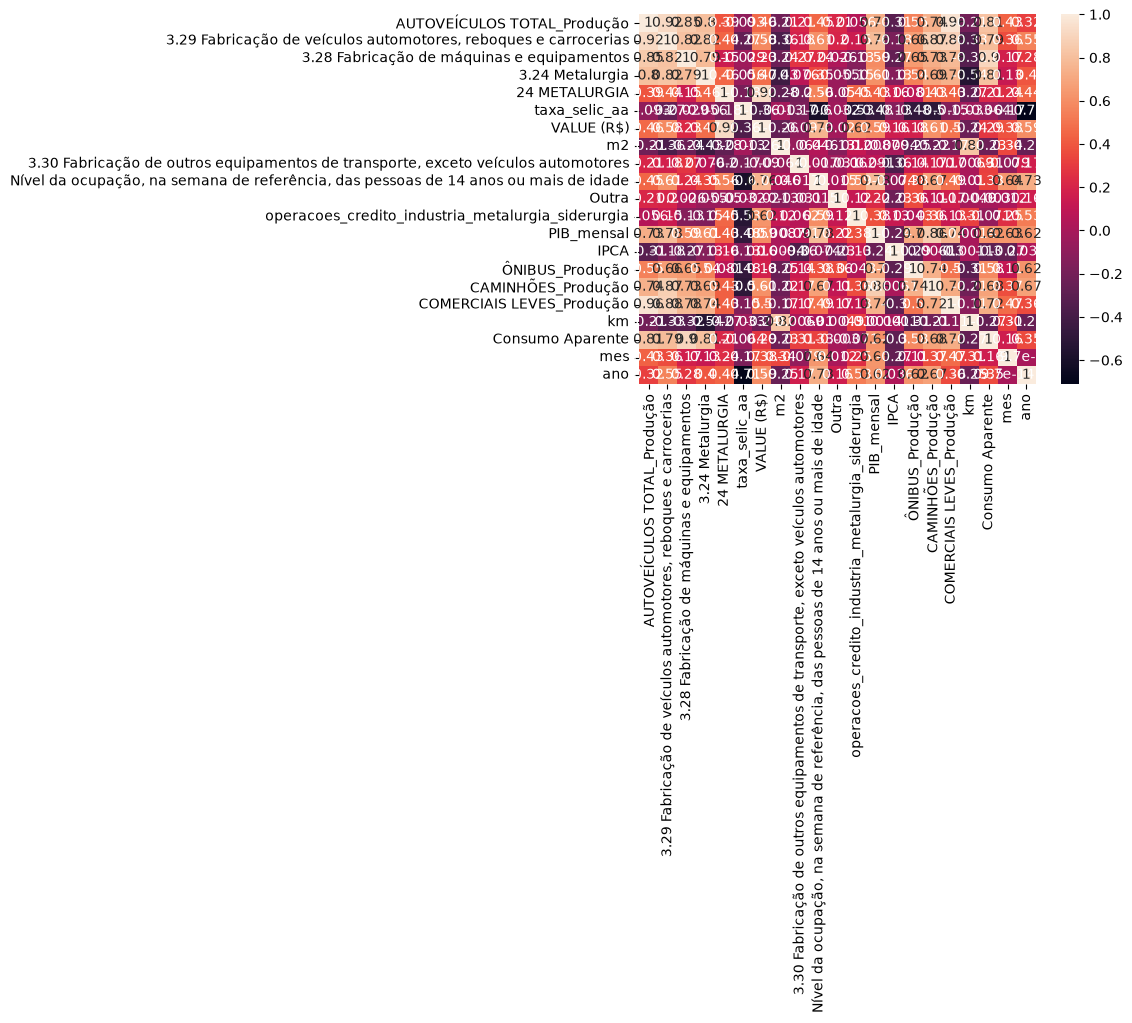

In [24]:
sns.heatmap(df_train.drop(['Date', 'Idade_Meses'], axis=1).corr(), annot=True)

In [25]:
df_test.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,Date,Consumo Aparente,mes,ano
0,181405,829.50313,822.00749,1161.03748,190.92377,12.816456,6.021173,3.421761e+07,485.84519,58.2,1.219462e+08,53299,957383.9,0.16,1806,8041,30754,135585.95,2025-01-01,860.019,1,2025
1,222641,892.80085,840.61394,1150.68202,187.23958,12.548696,5.765045,1.182539e+08,510.17106,58.0,2.571811e+08,53078,995276.2,1.31,2485,11970,42384,54361.16,2025-02-01,835.709,2,2025
2,194775,804.95627,903.90666,1293.36977,183.58373,12.148147,5.746216,2.805906e+09,499.19809,57.8,1.405650e+08,55179,1072062.7,0.56,2881,11720,36217,94316.74,2025-03-01,923.756,3,2025
3,232814,868.94550,870.19687,1255.71112,182.11066,13.488414,5.783085,2.278937e+07,602.83832,58.2,3.769977e+08,52386,1087637.4,0.43,2874,11020,45326,2567499.61,2025-04-01,874.506,4,2025
4,220078,851.82587,950.17380,1302.63000,175.80998,14.571181,5.666781,9.677494e+07,592.41836,58.6,1.123480e+08,53588,1061998.2,0.26,2920,12327,44477,126837.20,2025-05-01,887.499,5,2025


In [26]:
df_test.shape

(12, 22)

In [27]:
X_train = df_train.drop(['Date', 'Consumo Aparente', 'Idade_Meses'], axis=1)
y_train = df_train['Consumo Aparente']

X_test = df_test.drop(['Date', 'Consumo Aparente'], axis=1)
y_test = df_test['Consumo Aparente']

In [28]:
X_train.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,mes,ano
0,152666,671.81412,646.69370,1124.25388,164.95365,14.299605,5.200082,30803365.52,486.82985,56.6,7.726127e+07,52321,810360.0,0.53,782,4049,22775,211985.62,1,2023
1,161518,710.97903,705.83215,1116.09760,164.90123,11.616115,5.171089,17191716.66,529.17824,56.3,2.262894e+08,51793,831187.6,0.84,1275,8123,28426,144326.64,2,2023
2,221835,837.43781,919.00297,1252.34171,165.96857,14.979655,5.210861,35840097.80,564.49564,56.1,2.501142e+08,51226,939470.5,0.71,1958,12325,39890,106193.20,3,2023
3,178853,674.81187,699.58402,1198.02819,166.07286,11.616115,5.019133,22593184.97,468.77586,56.2,1.199447e+08,49358,910660.4,0.61,1628,7255,32421,636991.94,4,2023
4,227914,838.08819,763.44786,1233.79150,162.22799,14.299605,4.982241,31905252.22,541.22061,56.3,8.977490e+08,49601,911300.2,0.23,1947,8392,42524,1402051.93,5,2023


In [29]:
X_test.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,mes,ano
0,181405,829.50313,822.00749,1161.03748,190.92377,12.816456,6.021173,3.421761e+07,485.84519,58.2,1.219462e+08,53299,957383.9,0.16,1806,8041,30754,135585.95,1,2025
1,222641,892.80085,840.61394,1150.68202,187.23958,12.548696,5.765045,1.182539e+08,510.17106,58.0,2.571811e+08,53078,995276.2,1.31,2485,11970,42384,54361.16,2,2025
2,194775,804.95627,903.90666,1293.36977,183.58373,12.148147,5.746216,2.805906e+09,499.19809,57.8,1.405650e+08,55179,1072062.7,0.56,2881,11720,36217,94316.74,3,2025
3,232814,868.94550,870.19687,1255.71112,182.11066,13.488414,5.783085,2.278937e+07,602.83832,58.2,3.769977e+08,52386,1087637.4,0.43,2874,11020,45326,2567499.61,4,2025
4,220078,851.82587,950.17380,1302.63000,175.80998,14.571181,5.666781,9.677494e+07,592.41836,58.6,1.123480e+08,53588,1061998.2,0.26,2920,12327,44477,126837.20,5,2025


In [30]:
y_train.head()

0    753.383
1    700.768
2    935.049
3    794.998
4    815.353
Name: Consumo Aparente, dtype: float64

In [31]:
y_test.head()

0    860.019
1    835.709
2    923.756
3    874.506
4    887.499
Name: Consumo Aparente, dtype: float64

# Ajustar o modelo

In [32]:
# Esta é a sugestão de código para ser adicionada no final do seu notebook (exploracao_tabela_mestre.ipynb)
# O Optuna irá testar várias combinações de hiperparâmetros para encontrar a configuração com menor MSE.

def objective(trial):
    # Paramêtros com foco em combater overfitting (Regularizações)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 600),
        'max_depth': trial.suggest_int('max_depth', 2, 5), # Árvores mais rasas evitam overfitting extremo
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9), # Amostragem aleatória das observações
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9), # Amostragem parcial das colunas
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 15), # Restringe nós folhas muito específicos
        'gamma': trial.suggest_float('gamma', 1e-4, 5.0, log=True), # Redução mínima de perda para fazer um split
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True), # Regularização L1 nos pesos
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # Regularização L2
        'random_state': 0,
        'early_stopping_rounds': 20 # Tolerância de rounds sem melhora no eval_set
    }
    
    # Inicializa o modelo com os parâmetros sugeridos
    model_opt = XGBRegressor(**param)
    
    # O uso do eval_set junto do early_stopping permite parar o modelo se o overfitting começar se intensificar
    model_opt.fit(
        X_train, y_train, 
        sample_weight=pesos,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Previsão na base de teste
    y_pred_val = model_opt.predict(X_test)
    
    # Calculando a métrica que queremos minimizar (Mean Squared Error)
    error = mean_squared_error(y_test, y_pred_val)
    return error

# 1. Criação do Estudo do Optuna
# Se o Optuna não estiver instalado, instale com: !pip install optuna
study = optuna.create_study(direction='minimize')

# 2. Roda a otimização com 50 tentativas (pode aumentar n_trials para explorar mais)
study.optimize(objective, n_trials=50)

print('\nMelhores Parâmetros encontrados do XGBRegressor:')
print(study.best_params)
print(f'Menor MSE encontrado: {study.best_value}')

# 3. Treinando o modelo final com os melhores parâmetros achados (tiramos o early stopping para o fit final)
best_params = study.best_params
best_model = XGBRegressor(**best_params, random_state=0)
best_model.fit(X_train, y_train, sample_weight=pesos)

# 4. Avaliando a Performance do Melhor Modelo
y_pred_train_opt = best_model.predict(X_train)
y_pred_test_opt = best_model.predict(X_test)

mse_train_opt = np.round(mean_squared_error(y_train, y_pred_train_opt), 4)
r2_train_opt = np.round(r2_score(y_train, y_pred_train_opt), 4)
mae_train_opt = np.round(mean_absolute_error(y_train, y_pred_train_opt), 4)
mape_train_opt = np.round(mean_absolute_percentage_error(y_train, y_pred_train_opt), 4)

mse_test_opt = np.round(mean_squared_error(y_test, y_pred_test_opt), 4)
r2_test_opt = np.round(r2_score(y_test, y_pred_test_opt), 4)
mae_test_opt = np.round(mean_absolute_error(y_test, y_pred_test_opt), 4)
mape_test_opt = np.round(mean_absolute_percentage_error(y_test, y_pred_test_opt), 4)

[I 2026-06-30 06:33:50,008] A new study created in memory with name: no-name-8e4eeba8-f456-4839-a54e-35557f3df7c1
[I 2026-06-30 06:33:50,061] Trial 0 finished with value: 5491.095603133644 and parameters: {'n_estimators': 428, 'max_depth': 2, 'learning_rate': 0.045304785300981476, 'subsample': 0.8520537452846968, 'colsample_bytree': 0.6129339206611459, 'min_child_weight': 9, 'gamma': 0.07780985444460423, 'reg_alpha': 0.013325155913659391, 'reg_lambda': 0.013659858805246453}. Best is trial 0 with value: 5491.095603133644.
[I 2026-06-30 06:33:50,081] Trial 1 finished with value: 5535.995138977225 and parameters: {'n_estimators': 211, 'max_depth': 5, 'learning_rate': 0.040335676087924995, 'subsample': 0.6360613306763855, 'colsample_bytree': 0.75384256446955, 'min_child_weight': 12, 'gamma': 1.311041285853451, 'reg_alpha': 0.0067703623522678905, 'reg_lambda': 0.32245524736877446}. Best is trial 0 with value: 5491.095603133644.
[I 2026-06-30 06:33:50,100] Trial 2 finished with value: 5535.9


Melhores Parâmetros encontrados do XGBRegressor:
{'n_estimators': 242, 'max_depth': 3, 'learning_rate': 0.05092256126669979, 'subsample': 0.7509797386380666, 'colsample_bytree': 0.6568347129452844, 'min_child_weight': 5, 'gamma': 0.0003349973639787499, 'reg_alpha': 5.146251707787921, 'reg_lambda': 0.13337564985462977}
Menor MSE encontrado: 2021.7925763376313


In [33]:
print('-'*40)
print('--- Resultados com Tuning (Optuna) ---')
print(f'R2 Train: {r2_train_opt}')
print(f'MSE Train: {mse_train_opt}')
print(f'MAE Train: {mae_train_opt}')
print(f'MAPE Train: {mape_train_opt}')
print('')
print(f'R2 Test: {r2_test_opt}')
print(f'MSE Test: {mse_test_opt}')
print(f'MAE Test: {mae_test_opt}')
print(f'MAPE Test: {mape_test_opt}')

----------------------------------------
--- Resultados com Tuning (Optuna) ---
R2 Train: 0.8922
MSE Train: 669.0379
MAE Train: 22.0397
MAPE Train: 0.0265

R2 Test: 0.5898
MSE Test: 2077.3049
MAE Test: 42.393
MAPE Test: 0.0495


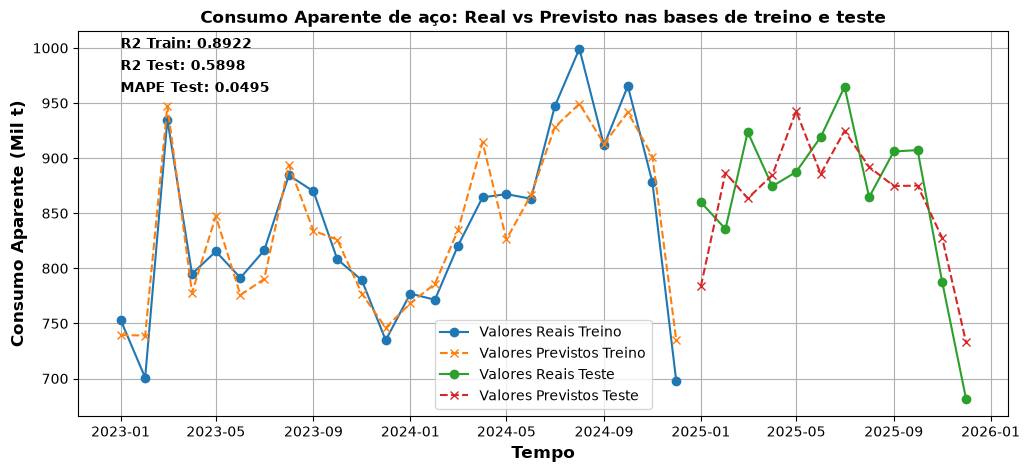

In [34]:
# Gráfico de Valores Reais vs Previstos
plt.figure(figsize=(12, 5))

plt.plot(df_train['Date'], y_train.values, label='Valores Reais Treino', marker='o')
plt.plot(df_train['Date'], y_pred_train_opt, label='Valores Previstos Treino', marker='x', linestyle='--')

plt.plot(df_test['Date'], y_test.values, label='Valores Reais Teste', marker='o')
plt.plot(df_test['Date'], y_pred_test_opt, label='Valores Previstos Teste', marker='x', linestyle='--')

plt.title('Consumo Aparente de aço: Real vs Previsto nas bases de treino e teste', fontsize=12, fontweight='bold')
plt.xlabel('Tempo', fontsize=12, fontweight='bold')
plt.ylabel('Consumo Aparente (Mil t)', fontsize=12, fontweight='bold')
plt.text(df_train.loc[0, 'Date'], 1000, f'R2 Train: {r2_train_opt}', fontweight='bold')
plt.text(df_train.loc[0, 'Date'], 980, f'R2 Test: {r2_test_opt}', fontweight='bold')
plt.text(df_train.loc[0, 'Date'], 960, f'MAPE Test: {mape_test_opt}', fontweight='bold')
plt.legend()
plt.grid()
plt.savefig(f'./{path_secao_atual}/real_x_predito_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Importância das variáveis

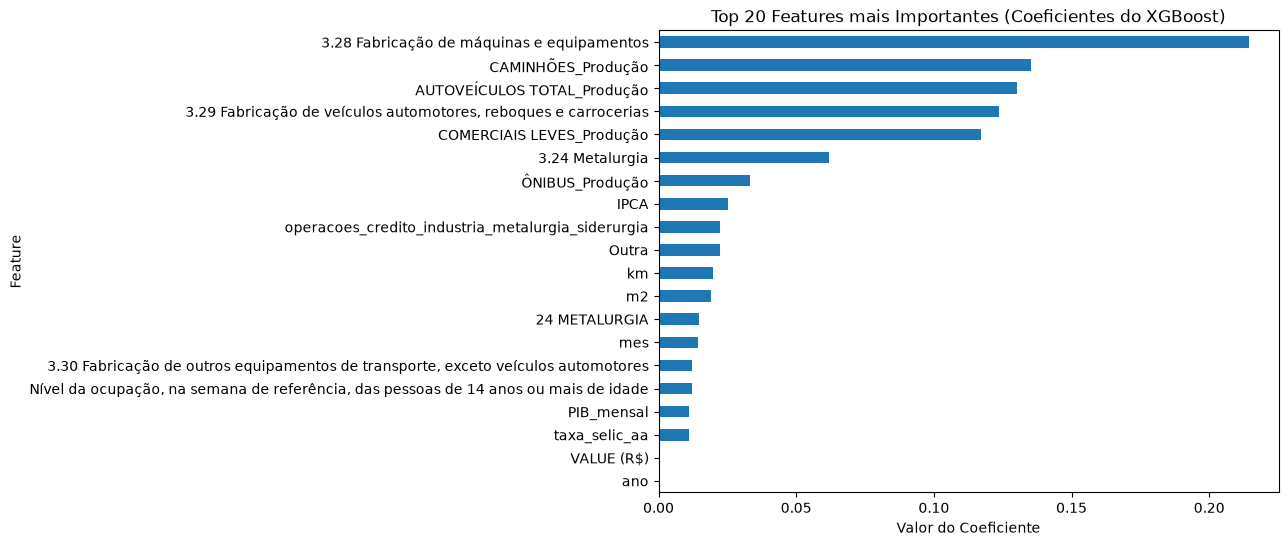

In [35]:
coefs = pd.Series(best_model.feature_importances_, index=best_model.feature_names_in_)

plt.figure(figsize=(8, 6))
coefs.sort_values(key=abs, ascending=True).tail(20).plot(kind='barh')
plt.title('Top 20 Features mais Importantes (Coeficientes do XGBoost)')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Feature')
plt.savefig(f'./{path_secao_atual}/top_20_features_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Salvar modelo

In [37]:
os.makedirs('./Modelos', exist_ok=True)
best_model_name = type(best_model).__name__
pickle.dump(best_model, open(f'./{path_secao_atual}/{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.pkl', 'wb'))

# Salvar dados utilizados na execução

In [38]:
df_valid_data = pd.concat([X_train, X_test]).copy()
df_valid_data['y_real'] = pd.Series(np.concat((y_train.values, y_test.values)))
df_valid_data['y_pred'] = pd.Series(np.concat((y_pred_train_opt, y_pred_test_opt)))
df_valid_data.reset_index(drop=True, inplace=True)
df_valid_data.to_excel(f'./{path_secao_atual}/valid_data_{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.xlsx', index=False, engine='openpyxl')

In [39]:
df_valid_data.head()

,AUTOVEÍCULOS TOTAL_Produção,"3.29 Fabricação de veículos automotores, reboques e carrocerias",3.28 Fabricação de máquinas e equipamentos,3.24 Metalurgia,24 METALURGIA,taxa_selic_aa,VALUE (R$),m2,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Outra,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,IPCA,ÔNIBUS_Produção,CAMINHÕES_Produção,COMERCIAIS LEVES_Produção,km,mes,ano,y_real,y_pred
0,152666,671.81412,646.69370,1124.25388,164.95365,14.299605,5.200082,30803365.52,486.82985,56.6,7.726127e+07,52321,810360.0,0.53,782,4049,22775,211985.62,1,2023,753.383,739.451721
1,161518,710.97903,705.83215,1116.09760,164.90123,11.616115,5.171089,17191716.66,529.17824,56.3,2.262894e+08,51793,831187.6,0.84,1275,8123,28426,144326.64,2,2023,700.768,738.995178
2,221835,837.43781,919.00297,1252.34171,165.96857,14.979655,5.210861,35840097.80,564.49564,56.1,2.501142e+08,51226,939470.5,0.71,1958,12325,39890,106193.20,3,2023,935.049,947.684448
3,178853,674.81187,699.58402,1198.02819,166.07286,11.616115,5.019133,22593184.97,468.77586,56.2,1.199447e+08,49358,910660.4,0.61,1628,7255,32421,636991.94,4,2023,794.998,777.762939
4,227914,838.08819,763.44786,1233.79150,162.22799,14.299605,4.982241,31905252.22,541.22061,56.3,8.977490e+08,49601,911300.2,0.23,1947,8392,42524,1402051.93,5,2023,815.353,847.370850


In [40]:
df_valid_data.shape

(36, 22)

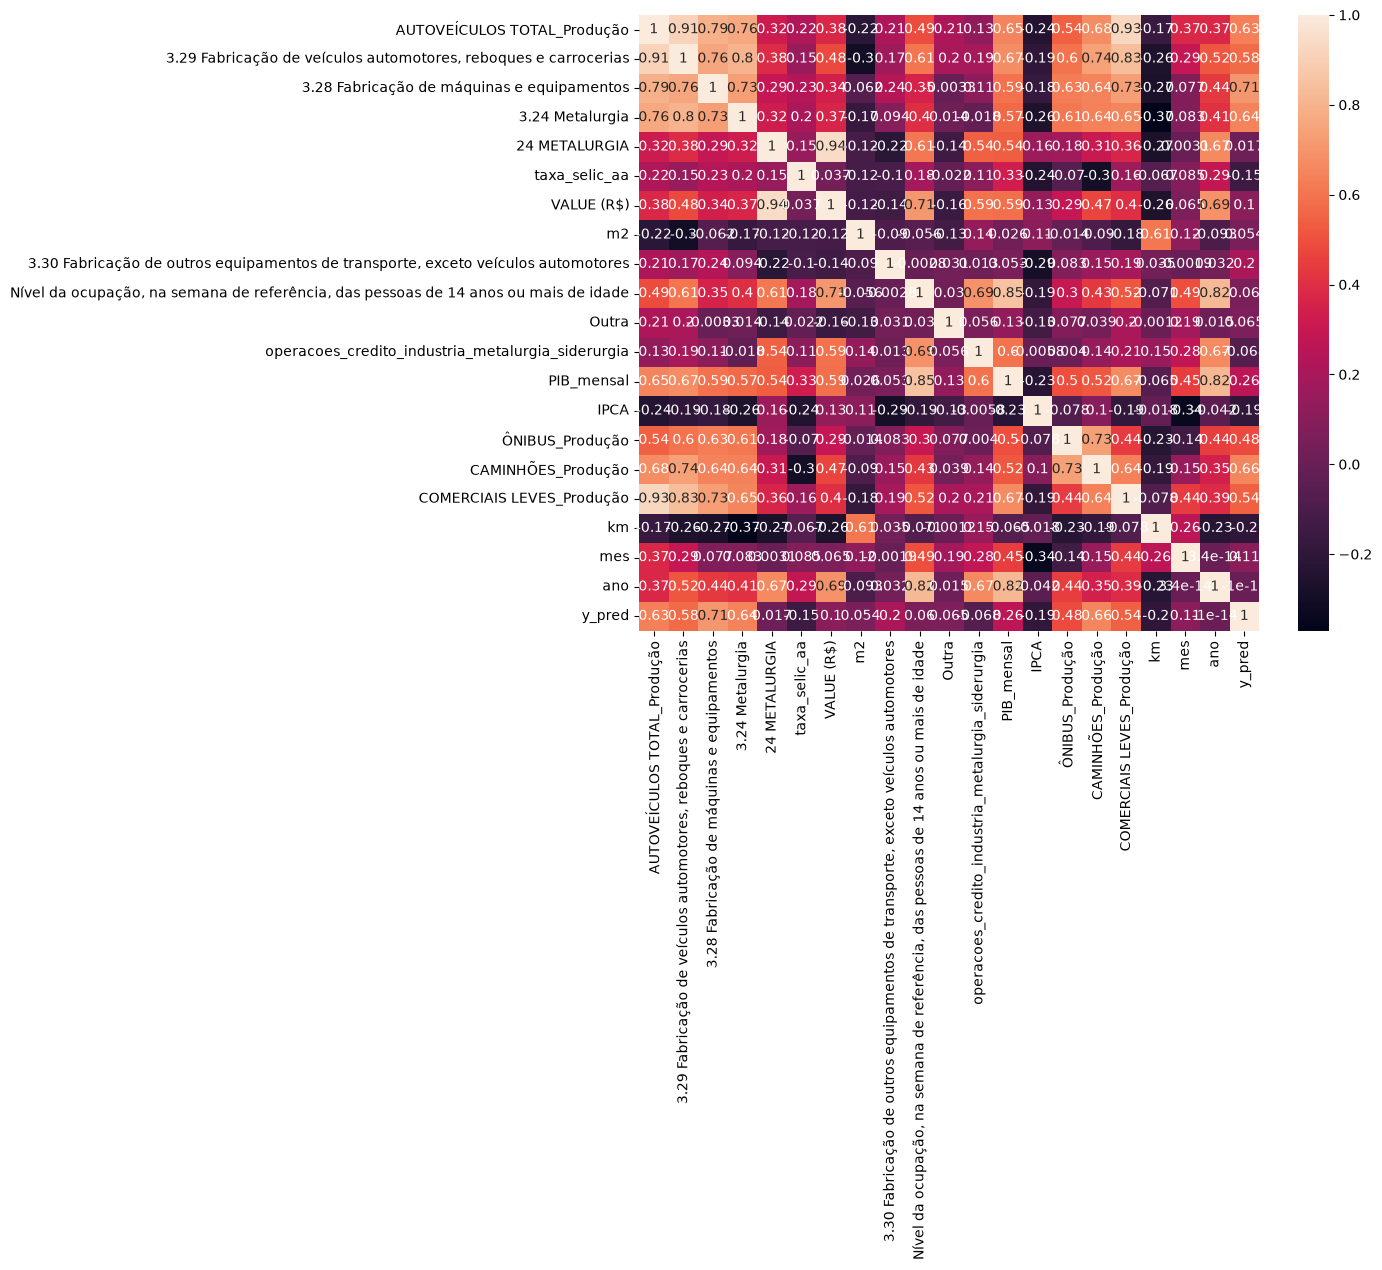

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_valid_data.drop('y_real', axis=1).corr(), annot=True)
plt.savefig(f'./{path_secao_atual}/correlation_matrix_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

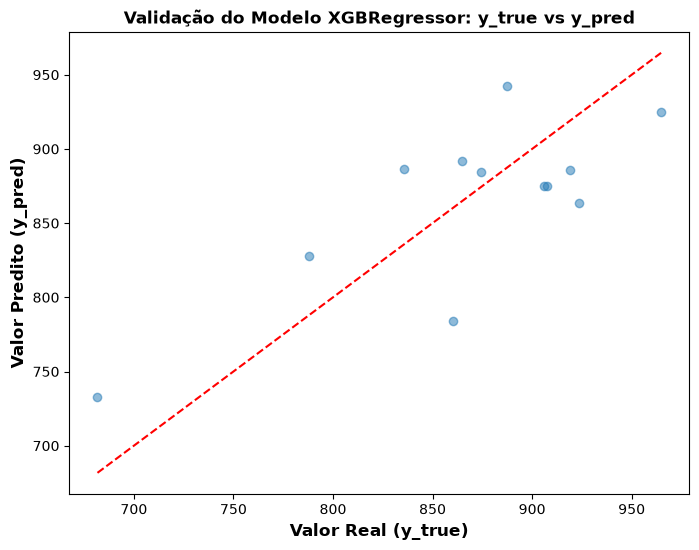

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(y_test.values, y_pred_test_opt, alpha=0.5)
min_val = min(np.min(y_test.values), np.min(y_pred_test_opt))
max_val = max(np.max(y_test.values), np.max(y_pred_test_opt))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Valor Real (y_true)', fontsize=12, fontweight='bold')
plt.ylabel('Valor Predito (y_pred)', fontsize=12, fontweight='bold')
plt.title(f'Validação do Modelo {best_model_name}: y_true vs y_pred', fontsize=12, fontweight='bold')
plt.savefig(f'./{path_secao_atual}/dispersion_y_true_x_y_pred_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')